# WiDS Datathon 2020 — ICU Mortality (`hospital_death`)

In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, brier_score_loss,
    precision_score, recall_score, f1_score, roc_auc_score,
)
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42



## Configuration, preprocessing class, and helpers
- **Missing cutoff (80%)**: drop *features* with >80% missing on train
- **Capacity cutoff (12%)**: flag top 12% highest-risk *patients*


In [232]:
# --- Policy constants ---
MISSING_RATE_CUTOFF = 0.80
MISSING_FLAG_MIN_RATE = 0.05
INTERVENTION_CAPACITY_PCT = 12.0
APACHE_PROB_COLS = ["apache_4a_hospital_death_prob", "apache_4a_icu_death_prob"]
APACHE_BASELINE_COL = "apache_4a_icu_death_prob"
ID_COLS = ["encounter_id", "patient_id", "icu_id", "hospital_id"]
TARGET_COL = "hospital_death"


def clean_apache_scores(series):
    s = series.replace(-1, np.nan)
    return s.fillna(s.median())


class WiDSFeatureBuilder(BaseEstimator, TransformerMixin):
    def __init__(self, missing_rate_cutoff=MISSING_RATE_CUTOFF,
                 missing_flag_min_rate=MISSING_FLAG_MIN_RATE, drop_cols=None):
        self.missing_rate_cutoff = missing_rate_cutoff
        self.missing_flag_min_rate = missing_flag_min_rate
        self.drop_cols = drop_cols or list(APACHE_PROB_COLS)

    def fit(self, X, y=None):
        X = X.copy()
        self.dropped_policy_cols_ = [c for c in self.drop_cols if c in X.columns]
        X = X.drop(columns=self.dropped_policy_cols_, errors="ignore")
        self.cat_cols_ = X.select_dtypes(include=["object"]).columns.tolist()
        self.num_cols_ = [c for c in X.columns if c not in self.cat_cols_]
        miss_rate = X[self.num_cols_].replace(-1, np.nan).isna().mean()
        self.sparse_cols_ = miss_rate[miss_rate > self.missing_rate_cutoff].index.tolist()
        self.keep_num_cols_ = [c for c in self.num_cols_ if c not in self.sparse_cols_]
        train_num = X[self.keep_num_cols_].replace(-1, np.nan)
        self.missing_flag_cols_ = [
            c for c in self.keep_num_cols_
            if train_num[c].isna().mean() > self.missing_flag_min_rate]
        self.num_medians_ = train_num.median()
        self.ohe_ = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
        if self.cat_cols_:
            self.ohe_.fit(X[self.cat_cols_].astype(str))
            self.ohe_feature_names_ = list(self.ohe_.get_feature_names_out(self.cat_cols_))
        else:
            self.ohe_feature_names_ = []
        self.feature_names_out_ = (
            self.keep_num_cols_
            + [f"{c}_is_missing" for c in self.missing_flag_cols_]
            + self.ohe_feature_names_)
        return self

    def transform(self, X):
        X = X.copy().drop(columns=self.dropped_policy_cols_, errors="ignore")
        num = X[self.keep_num_cols_].replace(-1, np.nan)
        num_imp = num.fillna(self.num_medians_)
        parts = [num_imp]
        if self.missing_flag_cols_:
            parts.append(pd.DataFrame(
                {f"{c}_is_missing": num[c].isna().astype(int) for c in self.missing_flag_cols_},
                index=X.index))
        if self.cat_cols_:
            enc = self.ohe_.transform(X[self.cat_cols_].astype(str))
            parts.append(pd.DataFrame(enc, columns=self.ohe_feature_names_, index=X.index))
        return pd.concat(parts, axis=1)[self.feature_names_out_]


def scale_pos_weight(y):
    return (y == 0).sum() / max((y == 1).sum(), 1)


def get_model_candidates(y_train, random_state=RANDOM_STATE):
    spw = scale_pos_weight(y_train)
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=1000, random_state=random_state, class_weight="balanced"),
        "Random Forest": RandomForestClassifier(
            n_estimators=100, random_state=random_state, n_jobs=-1, class_weight="balanced"),
        "XGBoost": XGBClassifier(
            random_state=random_state, eval_metric="logloss", n_jobs=-1, scale_pos_weight=spw),
        "LightGBM": LGBMClassifier(
            random_state=random_state, verbose=-1, n_jobs=-1, class_weight="balanced"),
        "CatBoost": CatBoostClassifier(
            random_state=random_state, verbose=0, auto_class_weights="Balanced",
            allow_writing_files=False),
    }


def _make_pipeline(name, model):
    if name in ("XGBoost", "LightGBM", "CatBoost", "Random Forest"):
        return Pipeline([("classifier", model)])
    return Pipeline([("scaler", StandardScaler()), ("classifier", model)])


def build_fitted_pipelines(X_train, y_train, random_state=RANDOM_STATE):
    fitted = {}
    for name, model in get_model_candidates(y_train, random_state).items():
        pipe = _make_pipeline(name, model)
        pipe.fit(X_train, y_train)
        fitted[name] = pipe
    return fitted


def cross_validate_models(X, y, n_splits=5, random_state=RANDOM_STATE):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []
    for name, model in get_model_candidates(y, random_state).items():
        scores = cross_val_score(_make_pipeline(name, model), X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
        rows.append({"model": name, "roc_auc_mean": scores.mean(), "roc_auc_std": scores.std()})
    return pd.DataFrame(rows).sort_values("roc_auc_mean", ascending=False)


def capacity_threshold(probabilities, capacity_pct=INTERVENTION_CAPACITY_PCT):
    return float(np.quantile(probabilities, 1.0 - capacity_pct / 100.0))


def negative_predictive_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else 0.0


def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0


def calculate_lift(actual, probabilities, num_bins=10):
    actual = np.asarray(actual)
    base_rate = np.sum(actual) / len(actual)
    order = np.argsort(probabilities)[::-1]
    bins = np.array_split(actual[order], num_bins)
    return [np.sum(b) / (len(b) * base_rate) for b in bins]


@dataclass
class OperatingPointMetrics:
    threshold: float
    capacity_pct: float
    sensitivity: float
    specificity: float
    ppv: float
    npv: float
    flagged_pct: float
    f1: float


def metrics_at_threshold(y_true, probabilities, threshold, capacity_pct=None):
    y_pred = (np.asarray(probabilities) >= threshold).astype(int)
    return OperatingPointMetrics(
        threshold=threshold,
        capacity_pct=capacity_pct if capacity_pct is not None else 100 * np.mean(y_pred),
        sensitivity=recall_score(y_true, y_pred, zero_division=0),
        specificity=specificity_score(y_true, y_pred),
        ppv=precision_score(y_true, y_pred, zero_division=0),
        npv=negative_predictive_value(y_true, y_pred),
        flagged_pct=100 * np.mean(y_pred),
        f1=f1_score(y_true, y_pred, zero_division=0),
    )


def probabilistic_metrics(y_true, probabilities):
    return {
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
        "brier": brier_score_loss(y_true, probabilities),
        "lift_at_10pct": calculate_lift(y_true, probabilities)[0],
    }


def build_summary_table(y_true, pipelines, X, capacity_pct=INTERVENTION_CAPACITY_PCT, apache_scores=None):
    rows = []
    for name, pipe in pipelines.items():
        probs = pipe.predict_proba(X)[:, 1]
        t = capacity_threshold(probs, capacity_pct)
        pm = probabilistic_metrics(y_true, probs)
        op = metrics_at_threshold(y_true, probs, t, capacity_pct)
        rows.append({
            "Model": name, "ROC AUC": pm["roc_auc"], "PR AUC": pm["pr_auc"], "Brier": pm["brier"],
            "Lift @10%": pm["lift_at_10pct"], "Threshold": t, "Sensitivity": op.sensitivity,
            "Specificity": op.specificity, "PPV": op.ppv, "NPV": op.npv,
            "% Flagged": op.flagged_pct, "F1 @cutoff": op.f1,
        })
    if apache_scores is not None:
        ac = clean_apache_scores(apache_scores)
        t = capacity_threshold(ac.values, capacity_pct)
        pm = probabilistic_metrics(y_true, ac)
        op = metrics_at_threshold(y_true, ac.values, t, capacity_pct)
        rows.append({
            "Model": "APACHE Baseline", "ROC AUC": pm["roc_auc"], "PR AUC": pm["pr_auc"],
            "Brier": pm["brier"], "Lift @10%": pm["lift_at_10pct"], "Threshold": t,
            "Sensitivity": op.sensitivity, "Specificity": op.specificity, "PPV": op.ppv,
            "NPV": op.npv, "% Flagged": op.flagged_pct, "F1 @cutoff": op.f1,
        })
    return pd.DataFrame(rows).round(3)



In [233]:
# Load raw data (IDs kept here for EDA; removed before modeling in preprocessing cell)
df = pd.read_csv("training_v2.csv")
print(f"Raw shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"ID columns present: {[c for c in ID_COLS if c in df.columns]}")


Raw shape: 91713 rows, 186 columns
ID columns present: ['encounter_id', 'patient_id', 'icu_id', 'hospital_id']


# Initial Dataset Analysis

In [234]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Shape: 91713 rows, 186 columns


In [235]:
# Check Target Variable 'hospital_death'
target_col = 'hospital_death'
if target_col in df.columns:
    print("\n--- Target Variable Distribution ---")
    target_counts = df[target_col].value_counts()
    target_pct = df[target_col].value_counts(normalize=True) * 100
    for val in target_counts.index:
        print(f"Class {val}: {target_counts[val]} ({target_pct[val]:.2f}%)")
else:
    print(f"\n[ERROR] Target column '{target_col}' not found!")


--- Target Variable Distribution ---
Class 0: 83798 (91.37%)
Class 1: 7915 (8.63%)


In [236]:
# Identify ID columns (high cardinality — dropped before train/val/test split)
id_cols = [c for c in ID_COLS if c in df.columns]
print("\n--- Identifiers & High-Cardinality Group IDs ---")
if not id_cols:
    print("No ID columns in df (already dropped).")
else:
    for col in id_cols:
        print(f"{col}: {df[col].nunique()} unique values")



--- Identifiers & High-Cardinality Group IDs ---
encounter_id: 91713 unique values
patient_id: 91713 unique values
icu_id: 241 unique values
hospital_id: 147 unique values


In [237]:
# Missing Values
print("\n--- Missing Data Summary ---")
missing_info = df.isna().sum()
missing_pct = (df.isna().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_info, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)

print(f"Total columns with missing data: {len(missing_df)} out of {df.shape[1]}")
print("\nTop 10 columns with the highest missing percentages:")
print(missing_df.head(10))


--- Missing Data Summary ---
Total columns with missing data: 175 out of 186

Top 10 columns with the highest missing percentages:
                      Missing Count  Percentage (%)
h1_bilirubin_max              84619       92.265001
h1_bilirubin_min              84619       92.265001
h1_lactate_min                84369       91.992411
h1_lactate_max                84369       91.992411
h1_albumin_max                83824       91.398166
h1_albumin_min                83824       91.398166
h1_pao2fio2ratio_min          80195       87.441257
h1_pao2fio2ratio_max          80195       87.441257
h1_arterial_ph_min            76424       83.329517
h1_arterial_ph_max            76424       83.329517


In [238]:
# Classify Column Types & Check Categorical Encoding Needs
print("\n--- Feature Type & Encoding Overview ---")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target and IDs from our feature count lists
if target_col in numeric_cols: numeric_cols.remove(target_col)
for col in id_cols:
    if col in numeric_cols: numeric_cols.remove(col)

print(f"Number of Numerical Features: {len(numeric_cols)}")
print(f"Number of Categorical Features: {len(categorical_cols)}")

if len(categorical_cols) > 0:
    print("\nCategorical columns and their unique value counts (for encoding planning):")
    for col in categorical_cols:
        print(f"  - {col}: {df[col].nunique()} unique values -> Sample: {df[col].dropna().unique()[:3]}")
else:
    print("No categorical columns detected.")


--- Feature Type & Encoding Overview ---
Number of Numerical Features: 173
Number of Categorical Features: 8

Categorical columns and their unique value counts (for encoding planning):
  - ethnicity: 6 unique values -> Sample: ['Caucasian' 'Hispanic' 'African American']
  - gender: 2 unique values -> Sample: ['M' 'F']
  - hospital_admit_source: 15 unique values -> Sample: ['Floor' 'Emergency Department' 'Operating Room']
  - icu_admit_source: 5 unique values -> Sample: ['Floor' 'Accident & Emergency' 'Operating Room / Recovery']
  - icu_stay_type: 3 unique values -> Sample: ['admit' 'readmit' 'transfer']
  - icu_type: 8 unique values -> Sample: ['CTICU' 'Med-Surg ICU' 'CCU-CTICU']
  - apache_3j_bodysystem: 11 unique values -> Sample: ['Sepsis' 'Respiratory' 'Metabolic']
  - apache_2_bodysystem: 10 unique values -> Sample: ['Cardiovascular' 'Respiratory' 'Metabolic']


# Preprocessing & splits (leakage-safe)


Additional features were explored based on the EDA findings, feature correlation analysis, and domain knowledge. These included indicators such as obesity and underweight BMI flags, elderly age indicators, pulse pressure, mean arterial pressure (MAP), and other derived physiological variables. However, experiments showed that most of these engineered features provided little to no improvement in predictive performance, and in some cases slightly degraded the results.

In [239]:
y = df[TARGET_COL]
X_raw = df.drop(columns=[TARGET_COL] + [c for c in ID_COLS if c in df.columns])
X_train_full, X_test_raw, y_train_full, y_test = train_test_split(
    X_raw, y, test_size=0.10, random_state=RANDOM_STATE, stratify=y)
X_train_raw, X_eval_raw, y_train, y_eval = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train_full)
apache_eval_scores = clean_apache_scores(X_eval_raw[APACHE_BASELINE_COL])


feature_builder = WiDSFeatureBuilder()
feature_builder.fit(X_train_raw)
X_train = feature_builder.transform(X_train_raw)
X_eval = feature_builder.transform(X_eval_raw)
X_test = feature_builder.transform(X_test_raw)
print(f"Train {X_train.shape} | Val {X_eval.shape} | Test {X_test.shape}")
print(f"Dropped {len(feature_builder.sparse_cols_)} sparse cols (>{MISSING_RATE_CUTOFF:.0%} missing)")
print(f"Added {len(feature_builder.missing_flag_cols_)} missing-indicator cols")



Train (70159, 277) | Val (12382, 277) | Test (9172, 277)
Dropped 32 sparse cols (>80% missing)
Added 80 missing-indicator cols


## 5-fold cross-validation (ROC-AUC)


In [240]:
cv_results = cross_validate_models(X_train, y_train, n_splits=5, random_state=RANDOM_STATE)
print(cv_results.to_string(index=False))
best_model_name = cv_results.iloc[0]["model"]
print(f"\nSelected model: {best_model_name}")
cv_results.to_csv("cv_model_comparison.csv", index=False)


              model  roc_auc_mean  roc_auc_std
           LightGBM      0.897802     0.004096
           CatBoost      0.895791     0.003654
Logistic Regression      0.883676     0.003677
            XGBoost      0.878844     0.004194
      Random Forest      0.876771     0.003145

Selected model: LightGBM


## Train models


In [241]:
fitted_pipelines = build_fitted_pipelines(X_train, y_train, random_state=RANDOM_STATE)
print("Trained:", ", ".join(fitted_pipelines.keys()))


Trained: Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost


## Capacity cutoff (top 12% risk)


In [242]:
intervention_threshold = capacity_threshold(
    fitted_pipelines[best_model_name].predict_proba(X_eval)[:, 1])
print(f"Validation capacity cutoff: {intervention_threshold:.4f} (top {INTERVENTION_CAPACITY_PCT:.0f}%)")


Validation capacity cutoff: 0.6844 (top 12%)


# Evaluation

In [243]:
color_palette = {
    'Logistic Regression': '#1f77b4',
    'Random Forest': '#e15759',
    'XGBoost': '#9467bd',
    'LightGBM': '#f28e2b',
    'CatBoost': '#17becf',
    'APACHE': '#bab0ac',
}


# Evaluation helpers (calculate_lift, build_summary_table, metrics_at_threshold, etc.)
# are defined in the helpers cell (cell 3). Plots and summary tables follow below.


Confusion Matrix

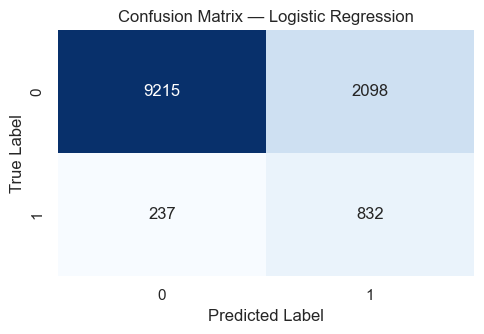

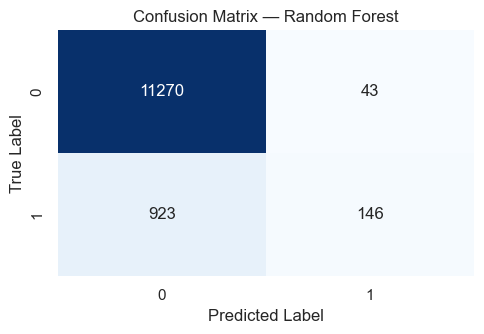

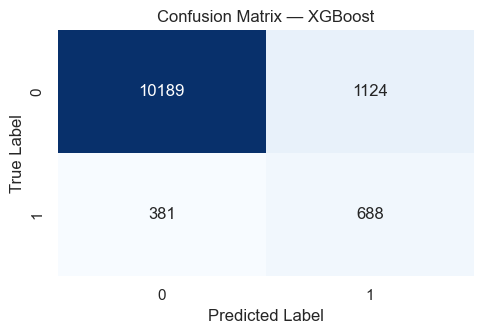

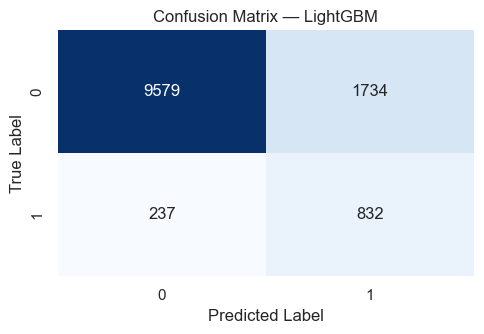

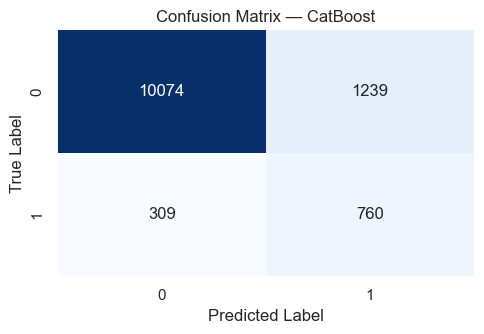

In [244]:
for name, pipeline in fitted_pipelines.items():
    preds = pipeline.predict(X_eval)
    cm = confusion_matrix(y_eval, preds)

    plt.figure(figsize=(5, 3.5))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', cbar=False)
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

Discrimination - ROC Curves

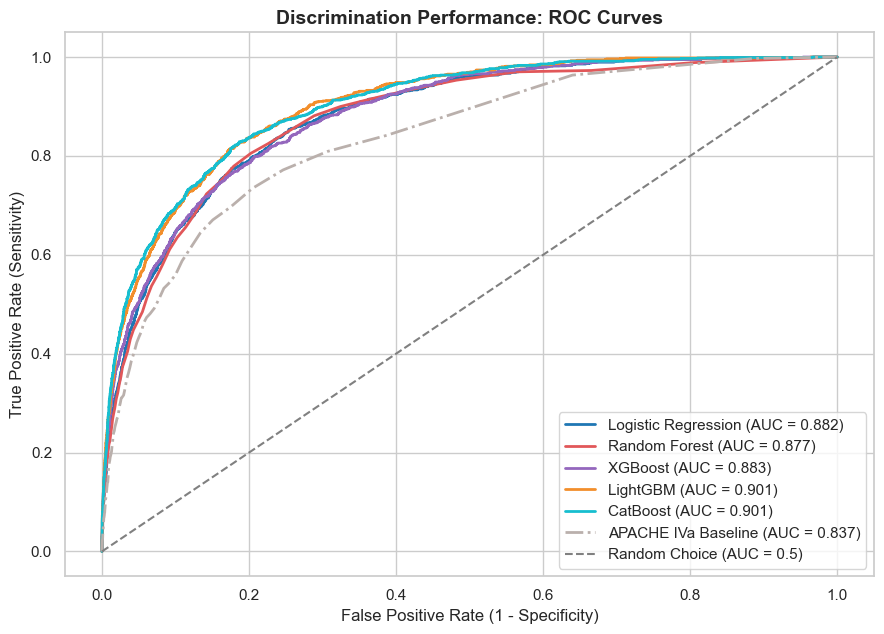

In [245]:
plt.figure(figsize=(9, 6.5))
plt.title('Discrimination Performance: ROC Curves', fontsize=14, fontweight='bold')

for name, pipeline in fitted_pipelines.items():
    y_scores = pipeline.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_eval, y_scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})", lw=2, color=color_palette[name])

fpr_ap, tpr_ap, _ = roc_curve(y_eval, apache_eval_scores)
plt.plot(fpr_ap, tpr_ap, label=f"APACHE IVa Baseline (AUC = {auc(fpr_ap, tpr_ap):.3f})", lw=2, color=color_palette['APACHE'], linestyle='-.')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Choice (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Precision-Recall Curves

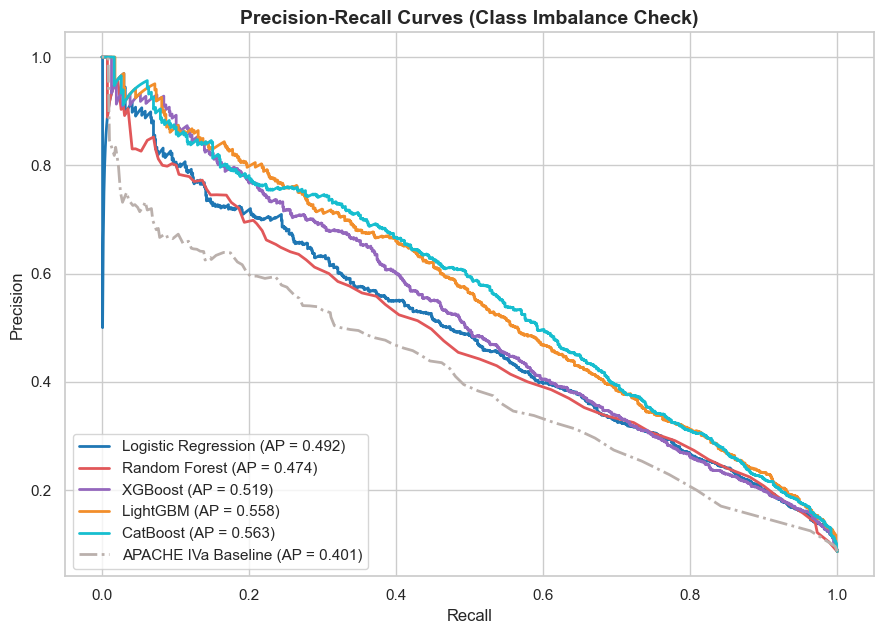

In [246]:
plt.figure(figsize=(9, 6.5))
plt.title('Precision-Recall Curves (Class Imbalance Check)', fontsize=14, fontweight='bold')

for name, pipeline in fitted_pipelines.items():
    y_scores = pipeline.predict_proba(X_eval)[:, 1]
    precision, recall, _ = precision_recall_curve(y_eval, y_scores)
    ap = average_precision_score(y_eval, y_scores)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})", lw=2, color=color_palette[name])

precision_ap, recall_ap, _ = precision_recall_curve(y_eval, apache_eval_scores)
ap_ap = average_precision_score(y_eval, apache_eval_scores)
plt.plot(recall_ap, precision_ap, label=f"APACHE IVa Baseline (AP = {ap_ap:.3f})", lw=2, color=color_palette['APACHE'], linestyle='-.')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

Calibration Plots

1. Smooth Calibration Plot

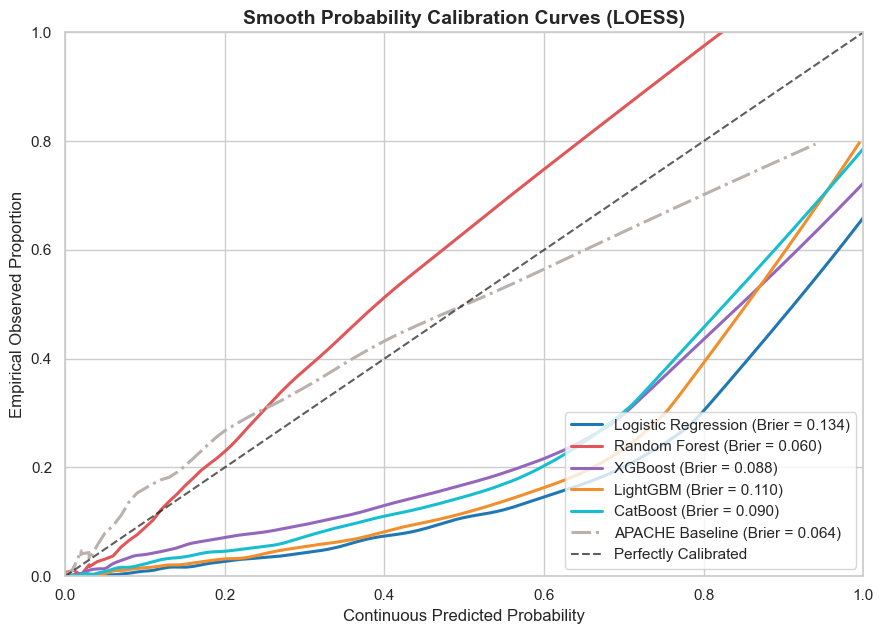

In [247]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

# Initialize the smooth calibration figure
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.set_title('Smooth Probability Calibration Curves (LOESS)', fontsize=14, fontweight='bold')

# 1. Plot Smooth Curves for ML Models
for name, pipeline in fitted_pipelines.items():
    y_scores = pipeline.predict_proba(X_eval)[:, 1]
    brier = brier_score_loss(y_eval, y_scores)

    # ADD JITTER: Add tiny random noise to break perfect ties at 0.0 or 1.0
    rng = np.random.default_rng(RANDOM_STATE)
    jittered_scores = y_scores + rng.uniform(-1e-6, 1e-6, size=len(y_scores))
    jittered_scores = np.clip(jittered_scores, 0, 1) # Keep within valid probability boundaries

    # Pass the jittered scores to lowess
    lowess_results = sm.nonparametric.lowess(y_eval, jittered_scores, frac=0.2, it=0)
    smoothed_pred, smoothed_true = lowess_results[:, 0], lowess_results[:, 1]

    # Sort for continuous plotting alignment
    sort_idx = np.argsort(smoothed_pred)
    ax.plot(smoothed_pred[sort_idx], smoothed_true[sort_idx],
            color=color_palette[name], lw=2.2, label=f'{name} (Brier = {brier:.3f})')

# 2. Plot Smooth Curve for APACHE Baseline
brier_ap = brier_score_loss(y_eval, apache_eval_scores)

# Add jitter to APACHE scores too
rng = np.random.default_rng(RANDOM_STATE)
jittered_apache = apache_eval_scores + rng.uniform(-1e-6, 1e-6, size=len(apache_eval_scores))
jittered_apache = np.clip(jittered_apache, 0, 1)

lowess_ap = sm.nonparametric.lowess(y_eval, jittered_apache, frac=0.2, it=0)
smoothed_pred_ap, smoothed_true_ap = lowess_ap[:, 0], lowess_ap[:, 1]
sort_idx_ap = np.argsort(smoothed_pred_ap)

ax.plot(smoothed_pred_ap[sort_idx_ap], smoothed_true_ap[sort_idx_ap],
        color=color_palette['APACHE'], linestyle='-.', lw=2.2,
        label=f'APACHE Baseline (Brier = {brier_ap:.3f})')

# 3. Reference Line and Formatting
ax.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Perfectly Calibrated')
ax.set_xlabel('Continuous Predicted Probability', fontsize=12)
ax.set_ylabel('Empirical Observed Proportion', fontsize=12)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

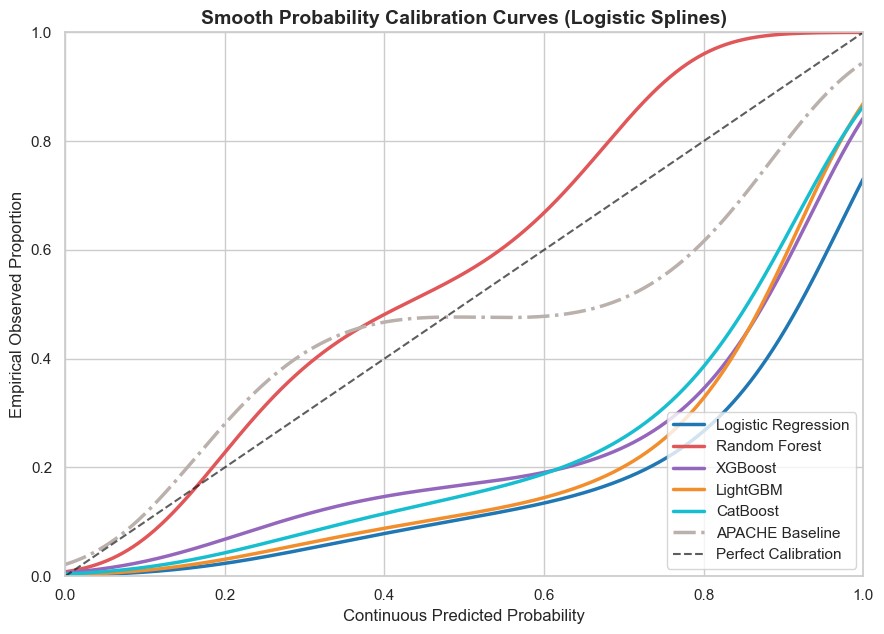

In [248]:
from patsy import dmatrix

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.set_title('Smooth Probability Calibration Curves (Logistic Splines)', fontsize=14, fontweight='bold')
eval_space = np.linspace(0, 1, 1000)

for name, pipeline in fitted_pipelines.items():
    y_scores = pipeline.predict_proba(X_eval)[:, 1]
    X_spline = dmatrix("bs(x, df=3, include_intercept=False)", {"x": y_scores}, return_type='dataframe')

    spline_model = LogisticRegression(C=1e10, max_iter=1000, solver='lbfgs')
    spline_model.fit(X_spline, y_eval)

    eval_spline = dmatrix("bs(x, df=3, include_intercept=False)", {"x": eval_space}, return_type='dataframe')
    smooth_trend = spline_model.predict_proba(eval_spline)[:, 1]
    ax.plot(eval_space, smooth_trend, color=color_palette[name], lw=2.5, label=name)

# Add APACHE spline
X_spline_ap = dmatrix("bs(x, df=3, include_intercept=False)", {"x": apache_eval_scores.values}, return_type='dataframe')
spline_model_ap = LogisticRegression(C=1e10, max_iter=1000, solver='lbfgs')
spline_model_ap.fit(X_spline_ap, y_eval)
eval_spline_ap = dmatrix("bs(x, df=3, include_intercept=False)", {"x": eval_space}, return_type='dataframe')
smooth_trend_ap = spline_model_ap.predict_proba(eval_spline_ap)[:, 1]
ax.plot(eval_space, smooth_trend_ap, color=color_palette['APACHE'], linestyle='-.', lw=2.5, label='APACHE Baseline')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Perfect Calibration')
ax.set_xlabel('Continuous Predicted Probability')
ax.set_ylabel('Empirical Observed Proportion')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


2. Strong Calibration Plot

**TODO**

Classification Metrics Triptych

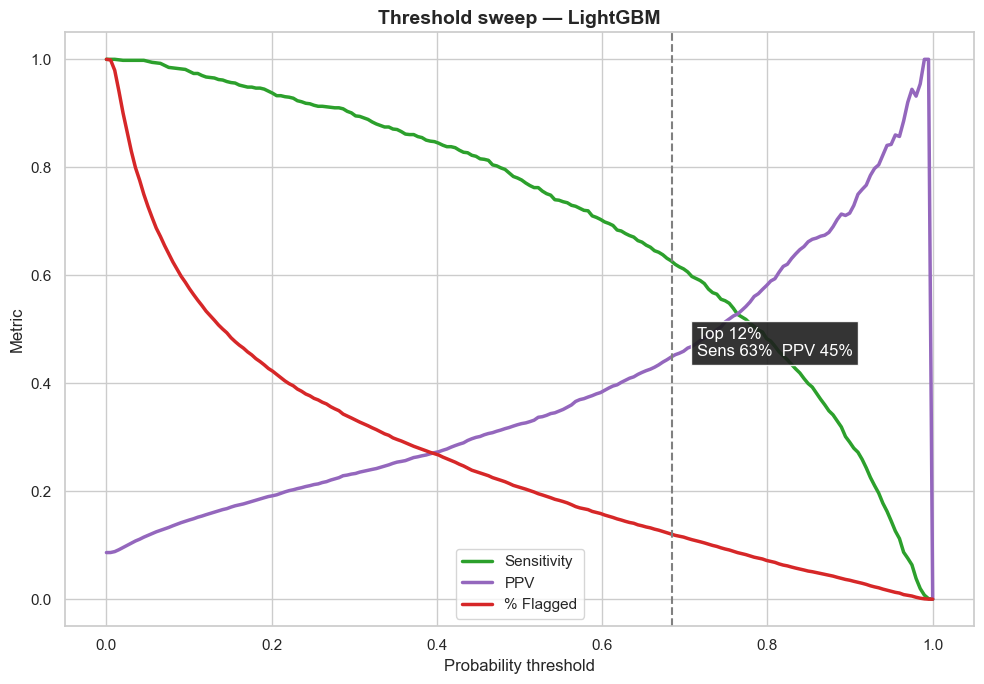

In [249]:
y_probs_best = fitted_pipelines[best_model_name].predict_proba(X_eval)[:, 1]
t_range = np.linspace(0, 1, 200)
sens_list, ppv_list, flag_list = [], [], []
for t in t_range:
    preds = (y_probs_best >= t).astype(int)
    tp = np.sum((preds == 1) & (y_eval == 1))
    sens_list.append(tp / np.sum(y_eval == 1))
    ppv_list.append(tp / np.sum(preds == 1) if np.sum(preds == 1) > 0 else 0)
    flag_list.append(np.sum(preds == 1) / len(y_eval))
plt.figure(figsize=(10, 7))
plt.title(f'Threshold sweep — {best_model_name}', fontsize=14, fontweight='bold')
plt.plot(t_range, sens_list, color='#2ca02c', lw=2.5, label='Sensitivity')
plt.plot(t_range, ppv_list, color='#9467bd', lw=2.5, label='PPV')
plt.plot(t_range, flag_list, color='#d62728', lw=2.5, label='% Flagged')
plt.axvline(intervention_threshold, color='gray', linestyle='--', lw=1.5)
op = metrics_at_threshold(y_eval, y_probs_best, intervention_threshold, INTERVENTION_CAPACITY_PCT)
plt.text(intervention_threshold + 0.03, 0.45,
         f"Top {INTERVENTION_CAPACITY_PCT:.0f}%\nSens {op.sensitivity*100:.0f}%  PPV {op.ppv*100:.0f}%",
         bbox=dict(facecolor='#1e1e1e', alpha=0.9), color='white')
plt.xlabel('Probability threshold'); plt.ylabel('Metric'); plt.legend(); plt.tight_layout(); plt.show()


Lift Curves

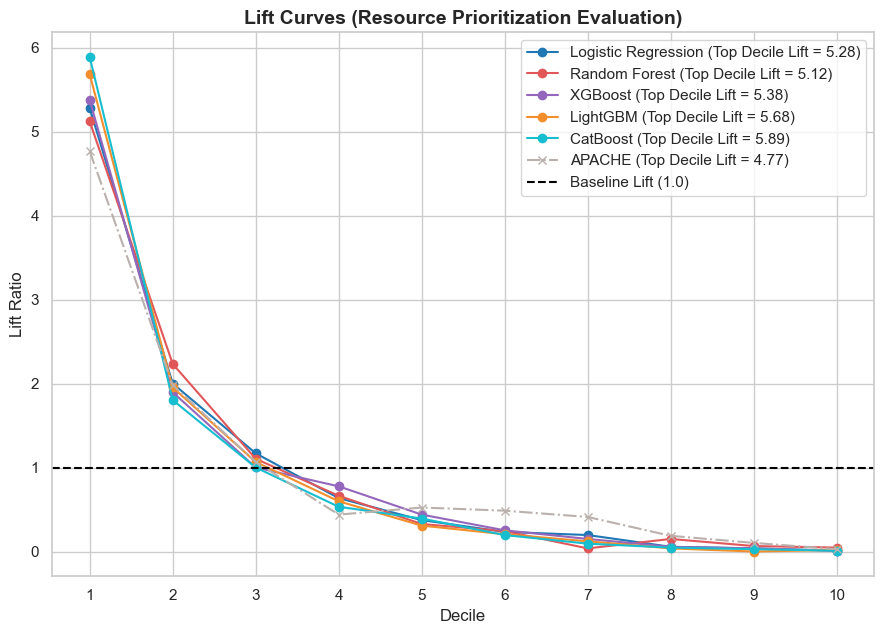

In [250]:
plt.figure(figsize=(9, 6.5))
plt.title('Lift Curves (Resource Prioritization Evaluation)', fontsize=14, fontweight='bold')

for name, pipeline in fitted_pipelines.items():
    y_scores = pipeline.predict_proba(X_eval)[:, 1]
    lift_scores = calculate_lift(y_eval, y_scores)
    plt.plot(range(1, 11), lift_scores, label=f'{name} (Top Decile Lift = {lift_scores[0]:.2f})', color=color_palette[name], marker='o')

lift_scores_ap = calculate_lift(y_eval, apache_eval_scores)
plt.plot(range(1, 11), lift_scores_ap, label=f'APACHE (Top Decile Lift = {lift_scores_ap[0]:.2f})', color=color_palette['APACHE'], linestyle='-.', marker='x')

plt.axhline(1, color='black', linestyle='--', label='Baseline Lift (1.0)')
plt.xlabel('Decile')
plt.ylabel('Lift Ratio')
plt.xticks(range(1, 11))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Final Metric Comparison Matrix Table

In [251]:
def negative_predictive_value(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    # tn = cm[0, 0], fn = cm[1, 0]
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else 0

In [252]:
summary_eval = build_summary_table(
    y_eval, fitted_pipelines, X_eval, apache_scores=apache_eval_scores)
print("\nValidation (each model @ 12% capacity):")
print(summary_eval.to_string(index=False))
summary_eval.to_csv("model_family_comparison_summary.csv", index=False)
test_probs = fitted_pipelines[best_model_name].predict_proba(X_test)[:, 1]
test_t = capacity_threshold(test_probs)
test_op = metrics_at_threshold(y_test, test_probs, test_t, INTERVENTION_CAPACITY_PCT)
test_pm = probabilistic_metrics(y_test, test_probs)
print(f"\nTest | {best_model_name}: AUC={test_pm['roc_auc']:.3f} PR-AUC={test_pm['pr_auc']:.3f}")
print(f"@ {INTERVENTION_CAPACITY_PCT:.0f}% capacity: Sens={test_op.sensitivity:.3f} PPV={test_op.ppv:.3f}")



Validation (each model @ 12% capacity):
              Model  ROC AUC  PR AUC  Brier  Lift @10%  Threshold  Sensitivity  Specificity   PPV   NPV  % Flagged  F1 @cutoff
Logistic Regression    0.882   0.492  0.134      5.282      0.722        0.580        0.923 0.417 0.959     12.001       0.485
      Random Forest    0.877   0.474  0.060      5.123      0.190        0.579        0.918 0.400 0.958     12.502       0.473
            XGBoost    0.883   0.519  0.088      5.375      0.580        0.585        0.924 0.421 0.959     12.001       0.489
           LightGBM    0.901   0.558  0.110      5.684      0.684        0.626        0.928 0.450 0.963     12.001       0.524
           CatBoost    0.901   0.563  0.090      5.890      0.607        0.634        0.929 0.456 0.964     12.001       0.531
    APACHE Baseline    0.837   0.401  0.064      4.768      0.140        0.532        0.916 0.374 0.954     12.284       0.439

Test | LightGBM: AUC=0.909 PR-AUC=0.605
@ 12% capacity: Sens=0.645 PP

Clinical Utility Evaluation (Net Benefit) - Decision Curve Analysis (DCA)

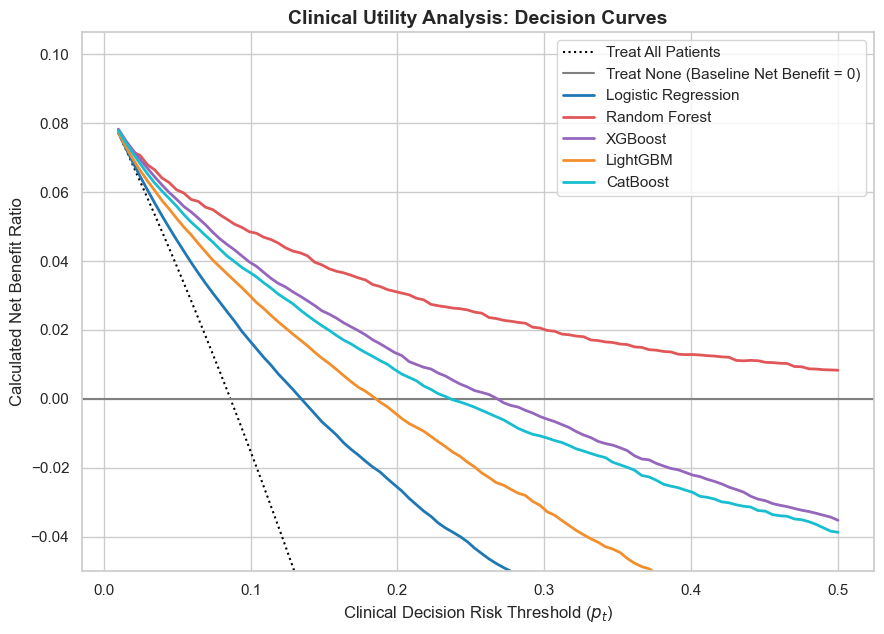

In [253]:
plt.figure(figsize=(9, 6.5))
plt.title('Clinical Utility Analysis: Decision Curves', fontsize=14, fontweight='bold')

# Calculate baseline strategies
pt_range = np.linspace(0.01, 0.50, 100)
net_benefit_all = []
prevalence = np.mean(y_eval)

for pt in pt_range:
    # Strategy: Treat All Patients
    tp_all = np.sum(y_eval == 1)
    fp_all = np.sum(y_eval == 0)
    nb_all = (tp_all / len(y_eval)) - (fp_all / len(y_eval)) * (pt / (1 - pt))
    net_benefit_all.append(nb_all)

plt.plot(pt_range, net_benefit_all, color='black', linestyle=':', label='Treat All Patients')
plt.axhline(0, color='gray', linestyle='-', label='Treat None (Baseline Net Benefit = 0)')

# Compute Net Benefit curves for each trained model candidate
for name, pipeline in fitted_pipelines.items():
    probs = pipeline.predict_proba(X_eval)[:, 1]
    nb_model = []
    for pt in pt_range:
        preds = (probs >= pt).astype(int)
        tp = np.sum((preds == 1) & (y_eval == 1))
        fp = np.sum((preds == 1) & (y_eval == 0))
        nb = (tp / len(y_eval)) - (fp / len(y_eval)) * (pt / (1 - pt))
        nb_model.append(nb)
    plt.plot(pt_range, nb_model, color=color_palette[name], lw=2, label=f'{name}')

plt.xlabel('Clinical Decision Risk Threshold ($p_t$)')
plt.ylabel('Calculated Net Benefit Ratio')
plt.ylim([-0.05, prevalence + 0.02])
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Save the model for future work

In [254]:
import joblib
import json
from pathlib import Path

save_dir = Path("best_model_info")
save_dir.mkdir(exist_ok=True)

best_model = fitted_pipelines[best_model_name]

# 1. Save preprocessing + fitted model
joblib.dump(feature_builder, save_dir / "feature_builder.joblib")
joblib.dump(best_model, save_dir / "best_model.joblib")

# 2. Save raw validation/test data
X_eval_raw.to_csv(save_dir / "X_eval_raw.csv", index=False)
y_eval.to_csv(save_dir / "y_eval.csv", index=False)

X_test_raw.to_csv(save_dir / "X_test_raw.csv", index=False)
y_test.to_csv(save_dir / "y_test.csv", index=False)

# 3. Save processed validation/test data
X_eval.to_csv(save_dir / "X_eval_processed.csv", index=False)
X_test.to_csv(save_dir / "X_test_processed.csv", index=False)

# 4. Save feature names
pd.Series(X_eval.columns, name="feature_name").to_csv(
    save_dir / "processed_feature_names.csv",
    index=False
)

# 5. Save validation predictions
eval_probs = best_model.predict_proba(X_eval)[:, 1]
eval_preds_at_cutoff = (eval_probs >= intervention_threshold).astype(int)

eval_predictions = pd.DataFrame({
    "y_true": y_eval.values,
    "predicted_probability": eval_probs,
    "flagged_top_12pct": eval_preds_at_cutoff
})

eval_predictions.to_csv(save_dir / "eval_predictions.csv", index=False)

# 6. Save test predictions
test_preds_at_cutoff = (test_probs >= test_t).astype(int)

test_predictions = pd.DataFrame({
    "y_true": y_test.values,
    "predicted_probability": test_probs,
    "flagged_top_12pct": test_preds_at_cutoff
})

test_predictions.to_csv(save_dir / "test_predictions.csv", index=False)

# 7. Save APACHE scores for comparison
pd.DataFrame({
    "y_true": y_eval.values,
    "apache_icu_death_prob": apache_eval_scores.values
}).to_csv(save_dir / "apache_eval_scores.csv", index=False)

# 8. Save summary tables
cv_results.to_csv(save_dir / "cv_model_comparison.csv", index=False)
summary_eval.to_csv(save_dir / "model_family_comparison_summary.csv", index=False)

# 9. Save metadata
metadata = {
    "best_model_name": best_model_name,
    "random_state": RANDOM_STATE,
    "target_col": TARGET_COL,
    "capacity_pct": INTERVENTION_CAPACITY_PCT,
    "validation_threshold_top_12pct": float(intervention_threshold),
    "test_threshold_top_12pct": float(test_t),
    "validation_metrics_at_cutoff": {
        "sensitivity": float(op.sensitivity),
        "specificity": float(op.specificity),
        "ppv": float(op.ppv),
        "npv": float(op.npv),
        "flagged_pct": float(op.flagged_pct),
        "f1": float(op.f1),
    },
    "test_metrics_at_cutoff": {
        "roc_auc": float(test_pm["roc_auc"]),
        "pr_auc": float(test_pm["pr_auc"]),
        "sensitivity": float(test_op.sensitivity),
        "specificity": float(test_op.specificity),
        "ppv": float(test_op.ppv),
        "npv": float(test_op.npv),
        "flagged_pct": float(test_op.flagged_pct),
        "f1": float(test_op.f1),
    },
    "dropped_sparse_columns": list(feature_builder.sparse_cols_),
    "missing_indicator_columns": list(feature_builder.missing_flag_cols_),
    "apache_probability_columns_removed_from_model": APACHE_PROB_COLS,
}

with open(save_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Saved info to: {save_dir.resolve()}")

Saved info to: /Users/tester/Desktop/מודלי חיזוי ברפואה/Project/best_model_info
